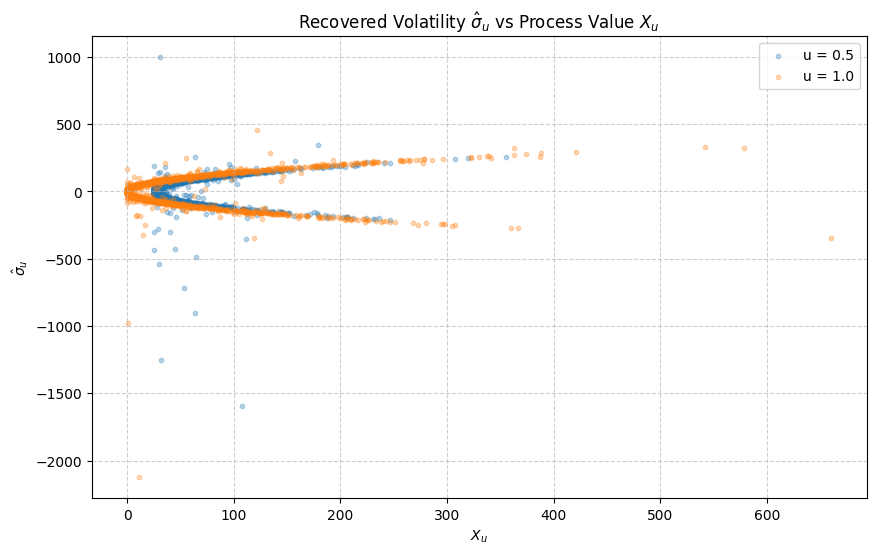

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Setup & Parameters ---
c0 = 50
c1 = 10
c2 = 100
T = 1.0
N = 1000      # Number of time steps
paths = 2000  # Number of simulated paths to get a dense scatter plot
dt = T / N
time_grid = np.linspace(0, T, N + 1)

# --- (a) Simulate paths (W, X) ---
# Generate Brownian motion increments and paths
dW = np.random.normal(0, np.sqrt(dt), (paths, N))
W = np.zeros((paths, N + 1))
W[:, 1:] = np.cumsum(dW, axis=1)

# The signature of a 1D Brownian motion up to level 2
# Sig^1_t = W_t
# Sig^2_t = (W_t^2 - t) / 2
sig1 = W
t_matrix = np.tile(time_grid, (paths, 1))
sig2 = (W**2 - t_matrix) / 2

# Calculate the signature model process X_t
X = c0 + c1 * sig1 + c2 * sig2

# --- (b) Find pairs (X_t, \hat{\sigma}_t) ---
# Calculate the increments of X
dX = np.diff(X, axis=1)

# \hat{\sigma}_t := dX_t / dW_t
# (Adding a tiny epsilon to the denominator prevents division by zero warnings)
sigma_hat = dX / (dW + 1e-12)

# --- (c) Plot \sigma_u over X_u for u = 0.5 and u = 1 ---
# Find the array indices corresponding to t = 0.5 and t = 1.0
# We subtract 1 because sigma_hat corresponds to the forward increment [t_i, t_{i+1}]
idx_05 = int(0.5 / dt) - 1
idx_10 = int(1.0 / dt) - 1

X_05 = X[:, idx_05]
sigma_05 = sigma_hat[:, idx_05]

X_10 = X[:, idx_10]
sigma_10 = sigma_hat[:, idx_10]

# Generate the plot
plt.figure(figsize=(10, 6))
plt.scatter(X_05, sigma_05, alpha=0.3, s=10, label='u = 0.5')
plt.scatter(X_10, sigma_10, alpha=0.3, s=10, label='u = 1.0')

plt.title('Recovered Volatility $\hat{\sigma}_u$ vs Process Value $X_u$')
plt.xlabel('$X_u$')
plt.ylabel('$\hat{\sigma}_u$')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# (d) Interpretation of the Plot

The plot displays two distinct, sideways-opening parabolas---one for $u = 0.5$ and one for $u = 1.0$. This behavior can be explained mathematically based on the definition of the signature.

## 1. Finding the theoretical $\sigma_t$
The signature levels of a 1-dimensional Brownian motion $W_t$ are defined as $S^1_t = W_t$ and $S^2_t = \frac{W_t^2 - t}{2}$. The model is given by:
\begin{equation*}
    X_t = c_0 + c_1 W_t + c_2 \frac{W_t^2 - t}{2}
\end{equation*}

By the definition of the signature, we have $dS^{n+1}_t = S^n_t dW_t$. Applying this to our model yields:
\begin{align*}
    dX_t &= c_1 dW_t + c_2 (W_t dW_t) \\
    dX_t &= (c_1 + c_2 W_t) dW_t
\end{align*}

Since the problem assumes $dX_t \approx \sigma(t, X_t) dW_t$, we can identify the true diffusion coefficient as:
\begin{equation*}
    \sigma_t = c_1 + c_2 W_t
\end{equation*}

## 2. The Relationship between $X_t$ and $\sigma_t$
To understand the plot of $\sigma_u$ over $X_u$, we express $X_t$ as a function of $\sigma_t$. Isolating $W_t$ from the volatility equation gives:
\begin{equation*}
    W_t = \frac{\sigma_t - c_1}{c_2}
\end{equation*}

Substituting $W_t$ back into the original signature model for $X_t$:
\begin{equation*}
    X_t = c_0 + c_1 \left( \frac{\sigma_t - c_1}{c_2} \right) + \frac{c_2}{2} \left[ \left( \frac{\sigma_t - c_1}{c_2} \right)^2 - t \right]
\end{equation*}

This equation demonstrates that $X_t$ is a quadratic function of $\sigma_t$. Since $X_t$ is plotted on the horizontal axis and $\sigma_t$ on the vertical axis, the resulting graph is a sideways parabola.

## 3. The Time Shift
The term $-\frac{c_2}{2} t$ in the equation above is deterministic and decreases the value of $X_t$ as time $t$ progresses. Due to this time dependency, the relationship between $X_t$ and $\sigma_t$ shifts over time. Therefore, the parabola for $u = 1.0$ maintains the same shape as the parabola for $u = 0.5$, but it is shifted to the left along the x-axis by exactly $\frac{c_2}{2} \Delta t$.